---
## Section 1 — Problem Statement

In the telecommunications industry, customer retention is a critical business imperative. Acquiring a new customer costs five to twenty-five times more than retaining an existing one. Despite this, most organisations rely on reactive retention strategies — acting only after a customer has already decided to leave.

This project addresses two core problems:
1. Traditional BI tools only answer *"How many customers left last month?"* — not *"Who will leave next month?"*
2. ML model outputs (F1-Score, Log Loss) are unintelligible to business managers.

The solution is an end-to-end system that builds a high-recall churn prediction model and deploys its outputs into a Power BI dashboard — converting churn probability scores into actionable customer risk profiles.

---
## Section 2 — Methodology

The project follows a six-stage pipeline:

```
Stage 1: Data Ingestion & Cleaning
         ↓
Stage 2: Exploratory Data Analysis (Univariate + Bivariate + Correlation)
         ↓
Stage 3: Feature Engineering & Encoding
         ↓
Stage 4: SMOTE Balancing + Train-Test Split
         ↓
Stage 5: Model Training with Hyperparameter Tuning (GridSearchCV)
         — Decision Tree (baseline)
         — Random Forest (primary)
         ↓
Stage 6: Evaluation + Prediction Export → Power BI Dashboard
```

**Key design choices:**
- SMOTE applied only to training data (never test) to avoid data leakage
- Recall prioritised over Accuracy for the Churn class — missing a churner is costlier than a false alarm
- Random Forest chosen for its ensemble robustness and built-in feature importance

---
## Section 3 — Data Description

**Dataset:** Telco Customer Churn (Kaggle, 2017)  
**Records:** 7,043 customers | **Attributes:** 21

| Category | Features |
|---|---|
| Demographics | gender, SeniorCitizen, Partner, Dependents |
| Services | PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies |
| Account Info | tenure, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges |
| Target | Churn (Yes/No) |

**Class imbalance:** 5,163 Non-Churners (73.4%) vs 1,869 Churners (26.6%) — addressed using SMOTE.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
# ─── DATA DESCRIPTION ────────────────────────────────────────────────────────

df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total Records   : {df_raw.shape[0]}")
print(f"Total Attributes: {df_raw.shape[1]}")

print("\n" + "=" * 60)
print("COLUMN INFO")
print("=" * 60)
print(f"{'Column':<25} {'Dtype':<12} {'Unique Values':<15} {'Null Count'}")
print("-" * 60)
for col in df_raw.columns:
    print(f"{col:<25} {str(df_raw[col].dtype):<12} {df_raw[col].nunique():<15} {df_raw[col].isnull().sum()}")

print("\n" + "=" * 60)
print("TARGET VARIABLE: Churn")
print("=" * 60)
churn_counts = df_raw['Churn'].value_counts()
for label, count in churn_counts.items():
    print(f"  {label:<5} : {count}  ({count/len(df_raw)*100:.1f}%)")

print("\n" + "=" * 60)
print("NUMERICAL FEATURE SUMMARY")
print("=" * 60)
print(df_raw[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2).to_string())

print("\n" + "=" * 60)
print("CATEGORICAL FEATURE SUMMARY")
print("=" * 60)
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
cat_cols.remove('customerID')
cat_cols.remove('Churn')
cat_cols.remove('TotalCharges')  # stored as string but is numeric
for col in cat_cols:
    print(f"\n{col}: {df_raw[col].unique().tolist()}")

print("\n" + "=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
# TotalCharges has hidden nulls (empty strings)
df_check = df_raw.copy()
df_check['TotalCharges'] = pd.to_numeric(df_check['TotalCharges'], errors='coerce')
nulls = df_check.isnull().sum()
null_cols = nulls[nulls > 0]
if len(null_cols) == 0:
    print("No missing values found (after type correction).")
else:
    print(null_cols)
    print(f"\nNote: {null_cols.sum()} rows with empty TotalCharges → new customers (tenure=0), imputed with 0.")

DATASET OVERVIEW
Total Records   : 7043
Total Attributes: 21

COLUMN INFO
Column                    Dtype        Unique Values   Null Count
------------------------------------------------------------
customerID                object       7043            0
gender                    object       2               0
SeniorCitizen             int64        2               0
Partner                   object       2               0
Dependents                object       2               0
tenure                    int64        73              0
PhoneService              object       2               0
MultipleLines             object       3               0
InternetService           object       3               0
OnlineSecurity            object       3               0
OnlineBackup              object       3               0
DeviceProtection          object       3               0
TechSupport               object       3               0
StreamingTV               object       3               0
S

---
## Section 4 — Implementation

### 4.1 — Data Ingestion & Cleaning

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Drop customerID — not a predictive feature
df.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges — empty strings coerced to NaN, then filled with 0 (new customers)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Null values remaining: {df.isnull().sum().sum()}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")

Null values remaining: 0

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


### 4.2 — Exploratory Data Analysis

#### 4.2.1 — Univariate Analysis: Class Imbalance

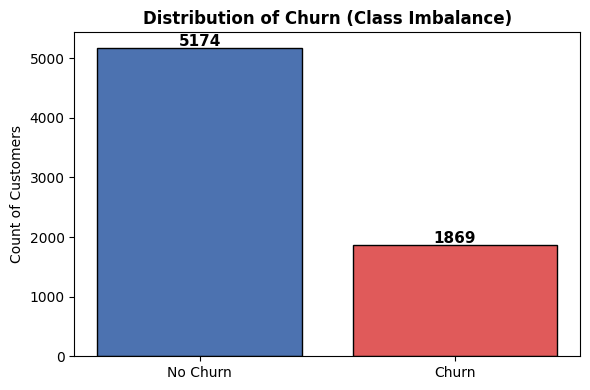

Non-Churners: 5174 (73.5%)
Churners    : 1869 (26.5%)


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Churn'].value_counts()
ax.bar(['No Churn', 'Churn'], counts.values, color=['#4C72B0', '#e05a5a'], edgecolor='black')
ax.set_title('Distribution of Churn (Class Imbalance)', fontweight='bold')
ax.set_ylabel('Count of Customers')
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_class_imbalance.png', dpi=150)
plt.show()
print(f"Non-Churners: {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"Churners    : {counts[1]} ({counts[1]/len(df)*100:.1f}%)")

#### 4.2.2 — Bivariate Analysis: Categorical Features vs Churn

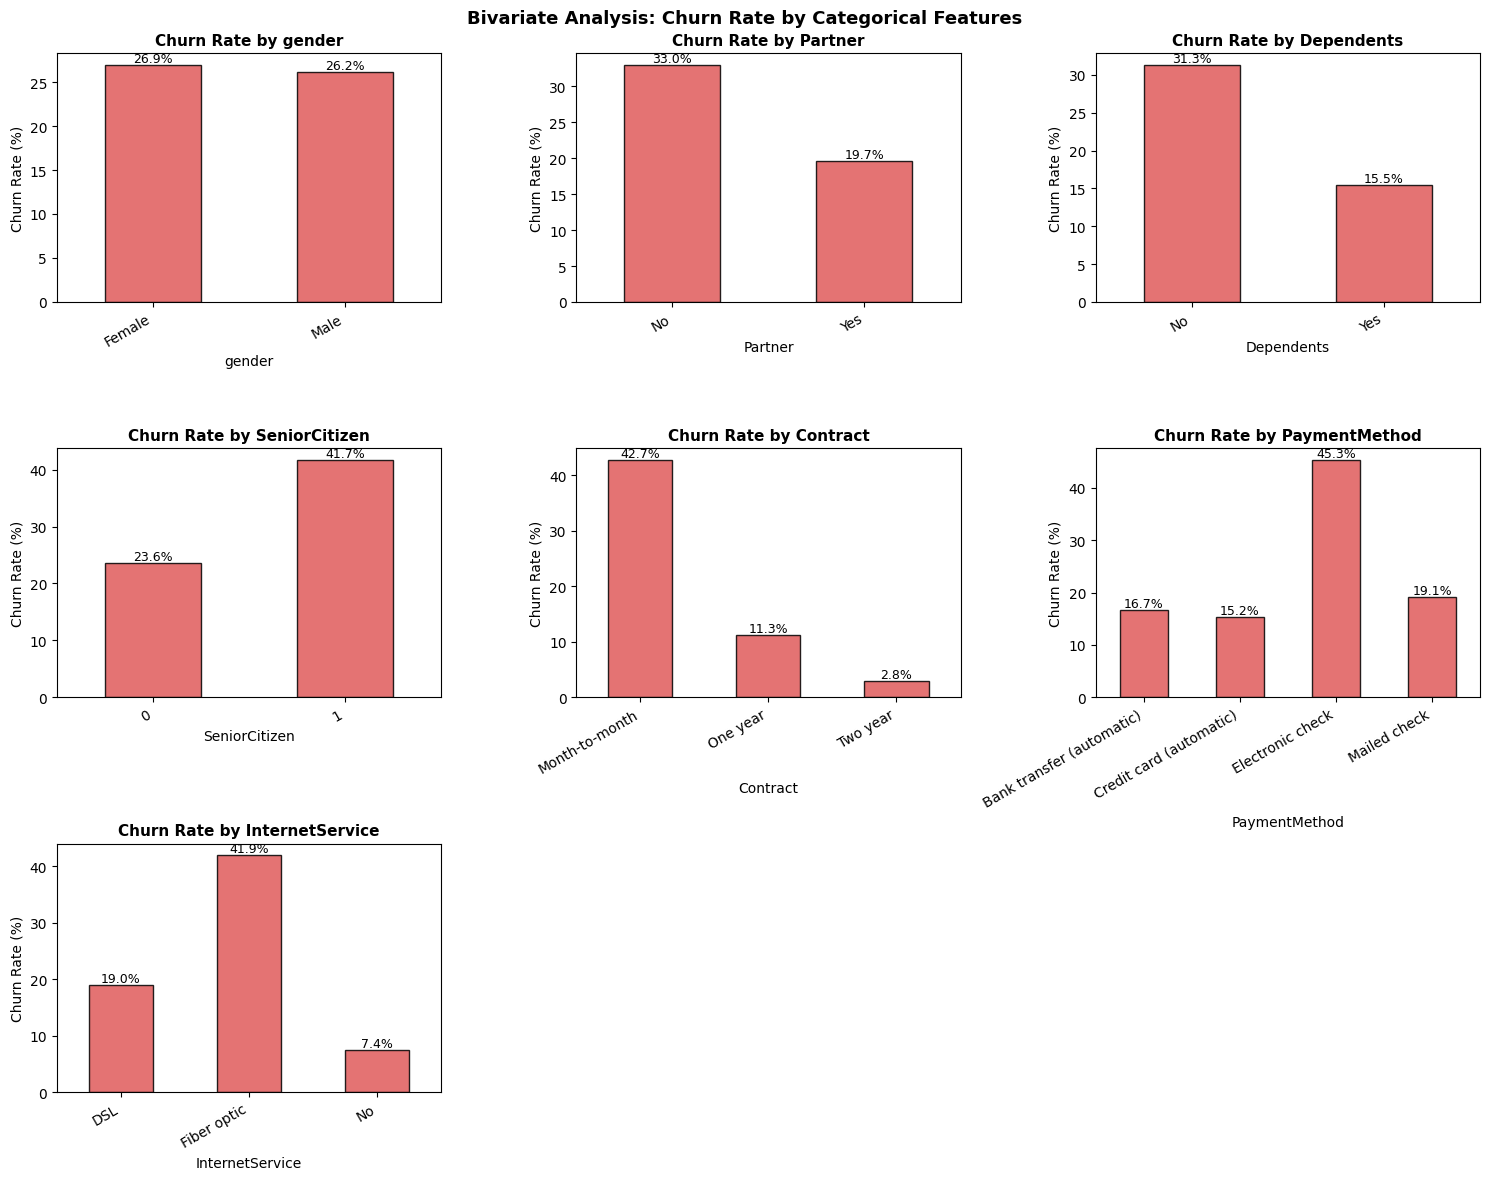

In [5]:
# Bivariate analysis — churn rate across key categorical variables
cat_features = ['gender', 'Partner', 'Dependents', 'SeniorCitizen',
                'Contract', 'PaymentMethod', 'InternetService']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    churn_rate.plot(kind='bar', ax=axes[i], color='#e05a5a', edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1f}%',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=9)

# Hide unused subplots
for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Bivariate Analysis: Churn Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_bivariate.png', dpi=150)
plt.show()

#### 4.2.3 — Correlation Heatmap: Numerical Features vs Churn

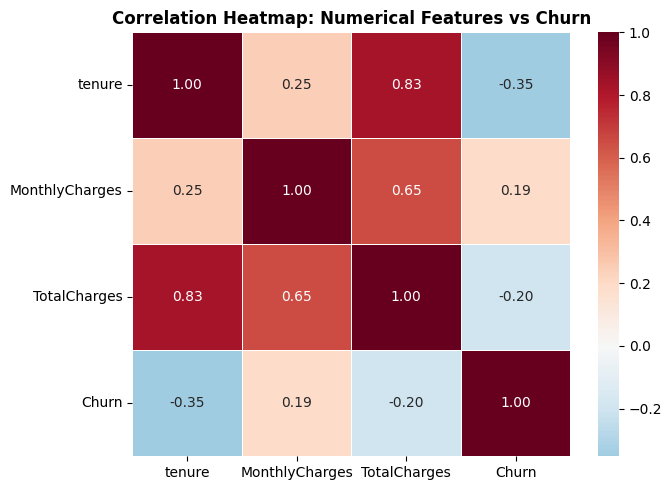

Key observations:
  tenure vs Churn       : -0.35  (longer tenure = less churn)
  MonthlyCharges vs Churn: 0.19  (higher charges = more churn)
  TotalCharges vs Tenure : 0.83  (multicollinearity noted)


In [6]:
# Correlation heatmap — numerical features only
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.5, linecolor='white',
    ax=ax
)
ax.set_title('Correlation Heatmap: Numerical Features vs Churn', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=150)
plt.show()

print("Key observations:")
print(f"  tenure vs Churn       : {corr_matrix.loc['tenure','Churn']:.2f}  (longer tenure = less churn)")
print(f"  MonthlyCharges vs Churn: {corr_matrix.loc['MonthlyCharges','Churn']:.2f}  (higher charges = more churn)")
print(f"  TotalCharges vs Tenure : {corr_matrix.loc['TotalCharges','tenure']:.2f}  (multicollinearity noted)")

### 4.3 — Feature Engineering & Encoding

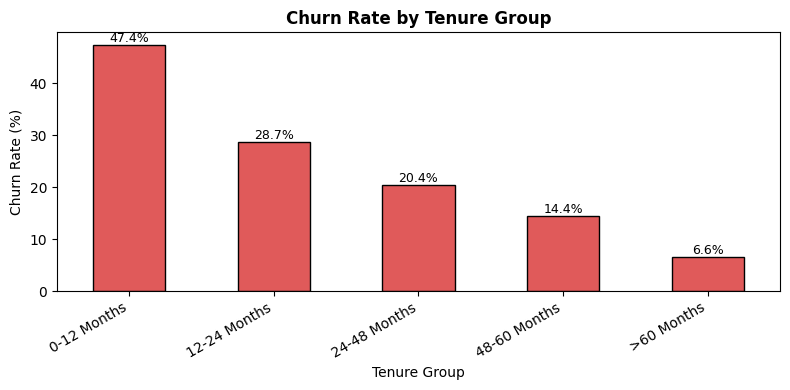

In [7]:
# Tenure Groups — visualise churn rate by customer longevity
bins = [0, 12, 24, 48, 60, df['tenure'].max()]
labels = ['0-12 Months', '12-24 Months', '24-48 Months', '48-60 Months', '>60 Months']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

fig, ax = plt.subplots(figsize=(8, 4))
tenure_churn = df.groupby('TenureGroup', observed=True)['Churn'].mean() * 100
tenure_churn.plot(kind='bar', color='#e05a5a', edgecolor='black', ax=ax)
ax.set_title('Churn Rate by Tenure Group', fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticklabels(labels, rotation=30, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('tenure_churn.png', dpi=150)
plt.show()

# Drop the group column — keep numeric tenure for model
df.drop('TenureGroup', axis=1, inplace=True)

In [8]:
# Label Encoding — binary columns
le = LabelEncoder()
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-Hot Encoding — multi-class columns
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
df[df.select_dtypes('bool').columns] = df.select_dtypes('bool').astype(int)

print(f"Final dataset shape: {df.shape}")
print(f"Total features for model: {df.shape[1] - 1}")

Final dataset shape: (7043, 31)
Total features for model: 30


### 4.4 — Train-Test Split & SMOTE Balancing

In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Stratified split — preserves 73/27 ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE applied only to training data — never the test set
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Training set (before SMOTE): {y_train.value_counts().to_dict()}")
print(f"Training set (after SMOTE) : {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"Test set (untouched)       : {y_test.value_counts().to_dict()}")

Training set (before SMOTE): {0: 4139, 1: 1495}
Training set (after SMOTE) : {0: 4139, 1: 4139}
Test set (untouched)       : {0: 1035, 1: 374}


### 4.5 — Hyperparameter Tuning with GridSearchCV

Instead of manually setting parameters, GridSearchCV exhaustively tests combinations using 5-fold cross-validation. Recall is used as the scoring metric — consistent with the business goal of catching as many churners as possible.

In [10]:
# --- Decision Tree Tuning ---
dt_param_grid = {
    'max_depth':        [4, 6, 8],
    'min_samples_leaf': [4, 8, 12]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(criterion='gini', random_state=42),
    dt_param_grid, cv=5, scoring='recall', n_jobs=-1
)
dt_grid.fit(X_train_sm, y_train_sm)

print("Decision Tree — Best Parameters:", dt_grid.best_params_)
print(f"Decision Tree — Best CV Recall : {dt_grid.best_score_:.4f}")

Decision Tree — Best Parameters: {'max_depth': 8, 'min_samples_leaf': 12}
Decision Tree — Best CV Recall : 0.8307


In [11]:
# --- Random Forest Tuning ---
rf_param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [4, 6, 8],
    'min_samples_leaf': [4, 8]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(criterion='gini', random_state=42),
    rf_param_grid, cv=5, scoring='recall', n_jobs=-1
)
rf_grid.fit(X_train_sm, y_train_sm)

print("Random Forest — Best Parameters:", rf_grid.best_params_)
print(f"Random Forest — Best CV Recall : {rf_grid.best_score_:.4f}")

# Use best estimators for all subsequent steps
best_dt = dt_grid.best_estimator_
best_rf = rf_grid.best_estimator_

Random Forest — Best Parameters: {'max_depth': 6, 'min_samples_leaf': 4, 'n_estimators': 100}
Random Forest — Best CV Recall : 0.8693


---
## Section 5 — Results

### 5.1 — Classification Reports

In [12]:
y_pred_dt = best_dt.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

print("=== Decision Tree (Tuned) ===")
print(classification_report(y_test, y_pred_dt, target_names=['No Churn', 'Churn']))

print("=== Random Forest (Tuned) ===")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

=== Decision Tree (Tuned) ===
              precision    recall  f1-score   support

    No Churn       0.88      0.76      0.81      1035
       Churn       0.51      0.70      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409

=== Random Forest (Tuned) ===
              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1035
       Churn       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



### 5.2 — Model Comparison Table

In [13]:
results = pd.DataFrame({
    'Model': ['Decision Tree (Tuned)', 'Random Forest (Tuned)'],
    'Accuracy':          [round(best_dt.score(X_test, y_test), 4), round(best_rf.score(X_test, y_test), 4)],
    'Precision (Churn)': [round(precision_score(y_test, y_pred_dt), 4), round(precision_score(y_test, y_pred_rf), 4)],
    'Recall (Churn)':    [round(recall_score(y_test, y_pred_dt), 4),    round(recall_score(y_test, y_pred_rf), 4)],
    'F1-Score (Churn)':  [round(f1_score(y_test, y_pred_dt), 4),        round(f1_score(y_test, y_pred_rf), 4)],
    'ROC-AUC':           [round(roc_auc_score(y_test, best_dt.predict_proba(X_test)[:,1]), 4),
                          round(roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]), 4)]
})
results

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn),ROC-AUC
0,Decision Tree (Tuned),0.7424,0.5107,0.7005,0.5908,0.7991
1,Random Forest (Tuned),0.7587,0.5324,0.7460,0.6214,0.8288


### 5.3 — Confusion Matrices

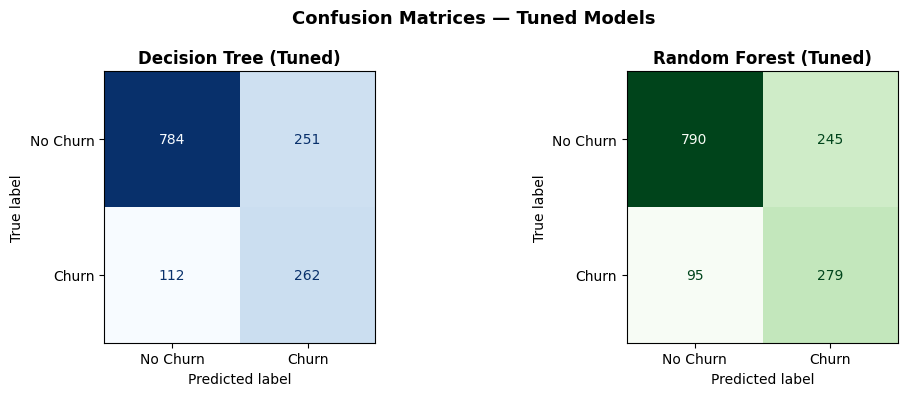

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, model, pred, title, cmap in [
    (axes[0], best_dt, y_pred_dt, 'Decision Tree (Tuned)', 'Blues'),
    (axes[1], best_rf, y_pred_rf, 'Random Forest (Tuned)', 'Greens')
]:
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrices — Tuned Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

### 5.4 — ROC Curve Comparison

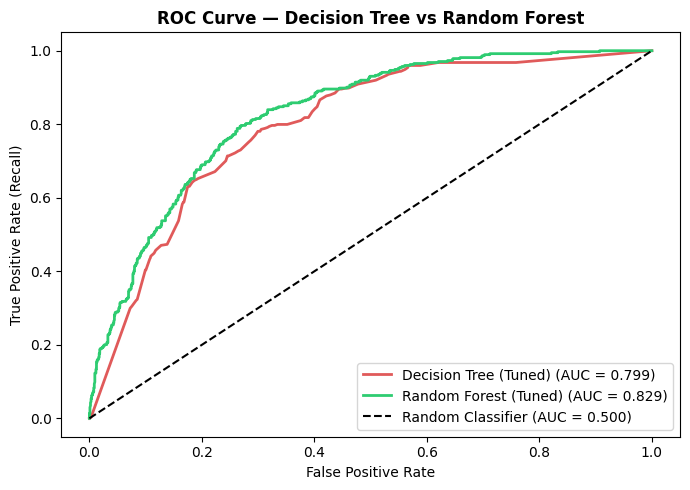

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

for model, name, color in [
    (best_dt, 'Decision Tree (Tuned)', '#e05a5a'),
    (best_rf, 'Random Forest (Tuned)', '#2ecc71')
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Decision Tree vs Random Forest', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

### 5.5 — Feature Importance (Random Forest)

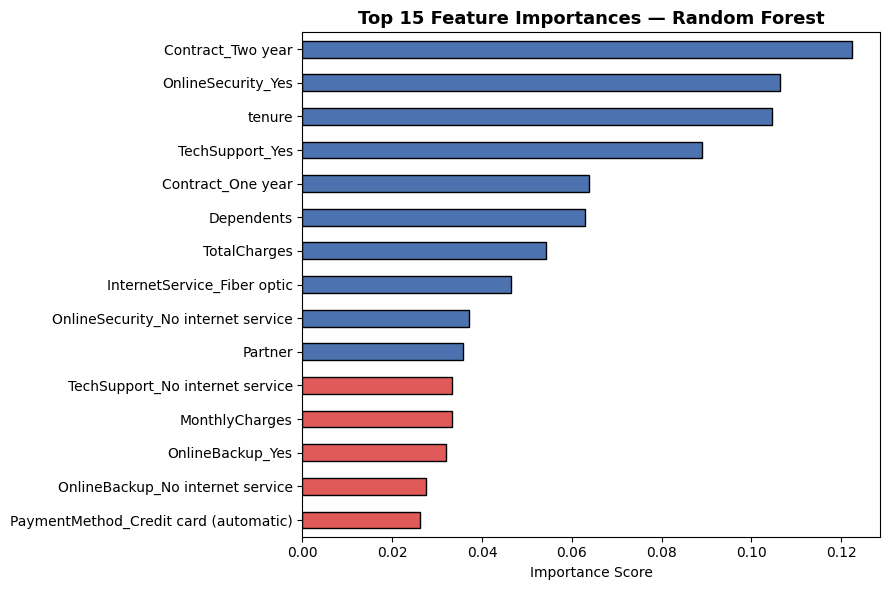

Top 5 churn drivers:
  Contract_Two year                             0.1225
  OnlineSecurity_Yes                            0.1063
  tenure                                        0.1047
  TechSupport_Yes                               0.0890
  Contract_One year                             0.0639


In [16]:
feature_importance = pd.Series(
    best_rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

top15 = feature_importance.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e05a5a' if i < 5 else '#4C72B0' for i in range(len(top15))]
top15.plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='black')
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("Top 5 churn drivers:")
for feat, score in feature_importance.head(5).items():
    print(f"  {feat:<45} {score:.4f}")

### 5.6 — Prediction Export for Power BI Dashboard

In [17]:
# Build export dataframe with predictions and risk labels
export_df = X_test.copy()
export_df['Actual_Churn']      = y_test.values
export_df['Predicted_Churn']   = best_rf.predict(X_test)
export_df['Churn_Probability'] = best_rf.predict_proba(X_test)[:, 1].round(4)
export_df['Risk_Level'] = pd.cut(
    export_df['Churn_Probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

export_df.to_csv('churn_predictions_powerbi.csv', index=False)

print(f"Exported {len(export_df)} records → 'churn_predictions_powerbi.csv'")
print(f"\nRisk Level Distribution:")
print(export_df['Risk_Level'].value_counts())
print(f"\nPredicted Churners (High + Medium Risk): {(export_df['Predicted_Churn']==1).sum()}")

export_df[['Churn_Probability', 'Predicted_Churn', 'Risk_Level']].head(10)

Exported 1409 records → 'churn_predictions_powerbi.csv'

Risk Level Distribution:
Risk_Level
Low Risk       618
High Risk      399
Medium Risk    392
Name: count, dtype: int64

Predicted Churners (High + Medium Risk): 524


,Churn_Probability,Predicted_Churn,Risk_Level
437,0.0480,0,Low Risk
2280,0.6423,1,High Risk
2235,0.1648,0,Low Risk
4460,0.5096,1,Medium Risk
3761,0.0910,0,Low Risk
5748,0.6422,1,High Risk
3568,0.5865,1,Medium Risk
2976,0.0725,0,Low Risk
5928,0.0096,0,Low Risk
1639,0.7255,1,High Risk
